# 03 Main Granularity and Segment Safety

Main-body experiment for Section 5.5. The notebook compares reporting partitions and shows how privacy-noise reduction from coarser cells trades off against hidden segment heterogeneity.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "privacy_robust_incrementality_measurement" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "code" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import ProjectPaths
paths = ProjectPaths.from_cwd(PROJECT_ROOT)
paths


ProjectPaths(project_root=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement'), code_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code'), data_dir=PosixPath('/home/apex/Documents/ranking_sys/data'), artifact_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts'), figure_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/figures'), table_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/tables'), workspace_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/workspace'))

In [2]:
from data import load_all
from experiments import granularity_results
from figures import plot_granularity
from tables import write_table
import pandas as pd

datasets = load_all(paths.data_dir)
results = pd.concat([granularity_results(ds) for ds in datasets.values()], ignore_index=True)
write_table(results, paths.table_dir / "granularity_segment_safety.csv")
summary = results.groupby(["dataset", "partition"], observed=True).agg(
    cells=("segment", "nunique"),
    median_rows=("rows", "median"),
    share_suppressed=("share_suppressed", "mean"),
    share_population_certified=("share_population_certified_cells", "mean"),
    share_population_unresolved=("share_population_unresolved_cells", "mean"),
    share_certified=("share_certified_cells", "mean"),
    share_segment_safe=("share_segment_safe", "mean"),
    share_segment_safe_rejected=("share_segment_safe_rejected", "mean"),
    share_segment_safe_unresolved=("share_segment_safe_unresolved", "mean"),
    mean_penalty=("heterogeneity_penalty", "mean"),
).reset_index()
write_table(summary, paths.table_dir / "granularity_segment_safety_summary.csv")
summary


,dataset,partition,cells,median_rows,share_suppressed,share_population_certified,share_population_unresolved,share_certified,share_segment_safe,share_segment_safe_rejected,share_segment_safe_unresolved,mean_penalty
0,Criteo Uplift,coarse_f0,4,500000.0,0.000000,0.250000,0.250000,0.0,0.0,0.0,1.0,3.487061e-03
1,Criteo Uplift,fine_f0_f1_f2,56,21746.0,0.053571,0.285714,0.178571,0.0,0.0,0.0,1.0,9.922386e-21
2,Criteo Uplift,medium_f0_f1,16,126449.0,0.000000,0.250000,0.250000,0.0,0.0,0.0,1.0,1.762130e-03
3,Criteo Uplift,very_fine_plus_exposure,107,2415.0,0.084112,0.028037,0.551402,0.0,0.0,0.0,1.0,5.193024e-21
4,Hillstrom Email,coarse_channel,3,28021.0,0.000000,1.000000,0.000000,0.0,0.0,0.0,1.0,5.361753e-02
5,Hillstrom Email,fine_channel_zip_history,57,657.0,0.087719,0.614035,0.263158,0.0,0.0,0.0,1.0,9.482117e-03
6,Hillstrom Email,medium_channel_zip,9,4238.0,0.000000,1.000000,0.000000,0.0,0.0,0.0,1.0,3.785398e-02
7,Hillstrom Email,very_fine_plus_recency,228,163.5,0.394737,0.359649,0.451754,0.0,0.0,0.0,1.0,7.560884e-20


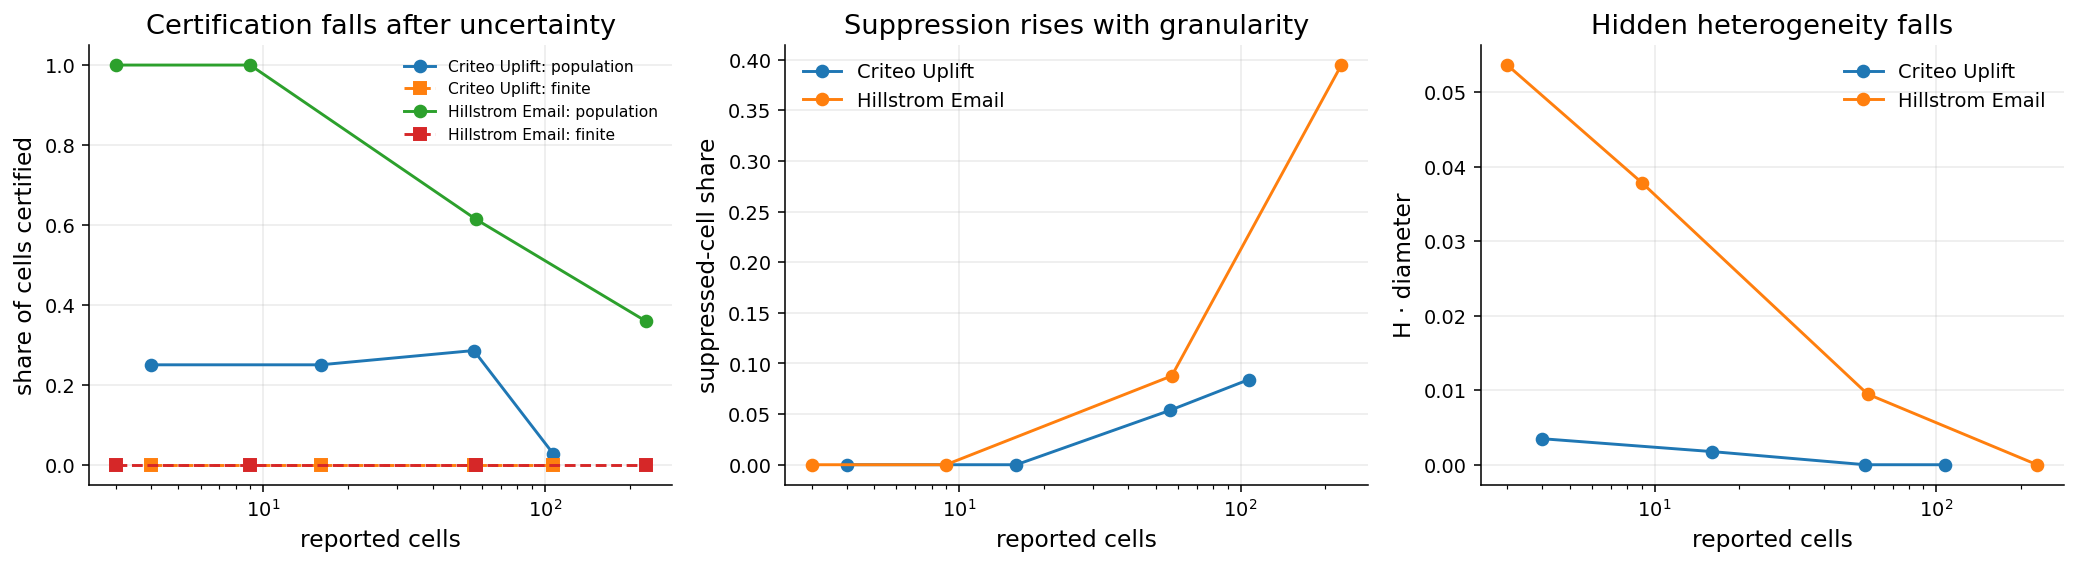

In [3]:
plot_granularity(results, paths.figure_dir / "granularity_tradeoff_main.png")
